In [ ]:
import numpy as np
import pandas as pd

# 1. DATA INPUT
x1 = np.array([45, 42, 44, 45, 43, 46, 44, 45, 44, 43])
x2 = np.array([16, 14, 15, 13, 13, 14, 16, 16, 15, 15])
y  = np.array([29, 24, 27, 25, 26, 28, 30, 28, 28, 27])
n  = len(y)

# 2. MENGHITUNG RATA-RATA (MEAN)
mean_x1 = np.mean(x1)
mean_x2 = np.mean(x2)
mean_y  = np.mean(y)

print(f"--- LANGKAH 1: RATA-RATA ---")
print(f"Rata-rata X1: {mean_x1}")
print(f"Rata-rata X2: {mean_x2}")
print(f"Rata-rata Y : {mean_y}\n")

# 3. MENGHITUNG DEVIASI (x = X - mean)
# Ini adalah inti dari Least Squares agar angka tidak terlalu besar
x1_dev = x1 - mean_x1
x2_dev = x2 - mean_x2
y_dev  = y - mean_y

# 4. MENGHITUNG JUMLAH KUADRAT & PRODUK DEVIASI
sum_x1_sq = np.sum(x1_dev**2)
sum_x2_sq = np.sum(x2_dev**2)
sum_x1_y  = np.sum(x1_dev * y_dev)
sum_x2_y  = np.sum(x2_dev * y_dev)
sum_x1_x2 = np.sum(x1_dev * x2_dev)

print(f"--- LANGKAH 2: KOMPONEN KUADRAT TERKECIL ---")
print(f"Σx1²  : {sum_x1_sq:.2f}")
print(f"Σx2²  : {sum_x2_sq:.2f}")
print(f"Σx1y  : {sum_x1_y:.2f}")
print(f"Σx2y  : {sum_x2_y:.2f}")
print(f"Σx1x2 : {sum_x1_x2:.2f}\n")

# 5. MENGHITUNG KOEFISIEN b1 DAN b2
# Menggunakan rumus Cramer untuk sistem 2 variabel (dari deviasi)
denominator = (sum_x1_sq * sum_x2_sq) - (sum_x1_x2**2)

b1 = ((sum_x2_sq * sum_x1_y) - (sum_x1_x2 * sum_x2_y)) / denominator
b2 = ((sum_x1_sq * sum_x2_y) - (sum_x1_x2 * sum_x1_y)) / denominator

print(f"--- LANGKAH 3: MENGHITUNG b1 DAN b2 ---")
print(f"b1 = {b1:.4f}")
print(f"b2 = {b2:.4f}\n")

# 6. MENGHITUNG KONSTANTA a
# a = mean_y - b1*mean_x1 - b2*mean_x2
a = mean_y - (b1 * mean_x1) - (b2 * mean_x2)

print(f"--- LANGKAH 4: MENGHITUNG KONSTANTA a ---")
print(f"a = {mean_y} - ({b1:.4f} * {mean_x1}) - ({b2:.4f} * {mean_x2})")
print(f"a = {a:.4f}\n")

print(f"PERSAMAAN AKHIR: Y = {a:.3f} + {b1:.3f}X1 + {b2:.3f}X2")

--- LANGKAH 1: RATA-RATA ---
Rata-rata X1: 44.1
Rata-rata X2: 14.7
Rata-rata Y : 27.2

--- LANGKAH 2: KOMPONEN KUADRAT TERKECIL ---
Σx1²  : 12.90
Σx2²  : 12.10
Σx1y  : 9.80
Σx2y  : 14.60
Σx1x2 : 2.30

--- LANGKAH 3: MENGHITUNG b1 DAN b2 ---
b1 = 0.5637
b2 = 1.0995

--- LANGKAH 4: MENGHITUNG KONSTANTA a ---
a = 27.2 - (0.5637 * 44.1) - (1.0995 * 14.7)
a = -13.8196

PERSAMAAN AKHIR: Y = -13.820 + 0.564X1 + 1.099X2


<>:29: SyntaxWarning: invalid escape sequence '\h'
<>:40: SyntaxWarning: invalid escape sequence '\h'
<>:29: SyntaxWarning: invalid escape sequence '\h'
<>:40: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_3237/764987381.py:29: SyntaxWarning: invalid escape sequence '\h'
  ax1.set_xlabel('Nilai Prediksi ($\hat{Y}$)', fontsize=12)
/tmp/ipykernel_3237/764987381.py:40: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_xlabel('Nilai Prediksi ($\hat{Y}$)', fontsize=12)


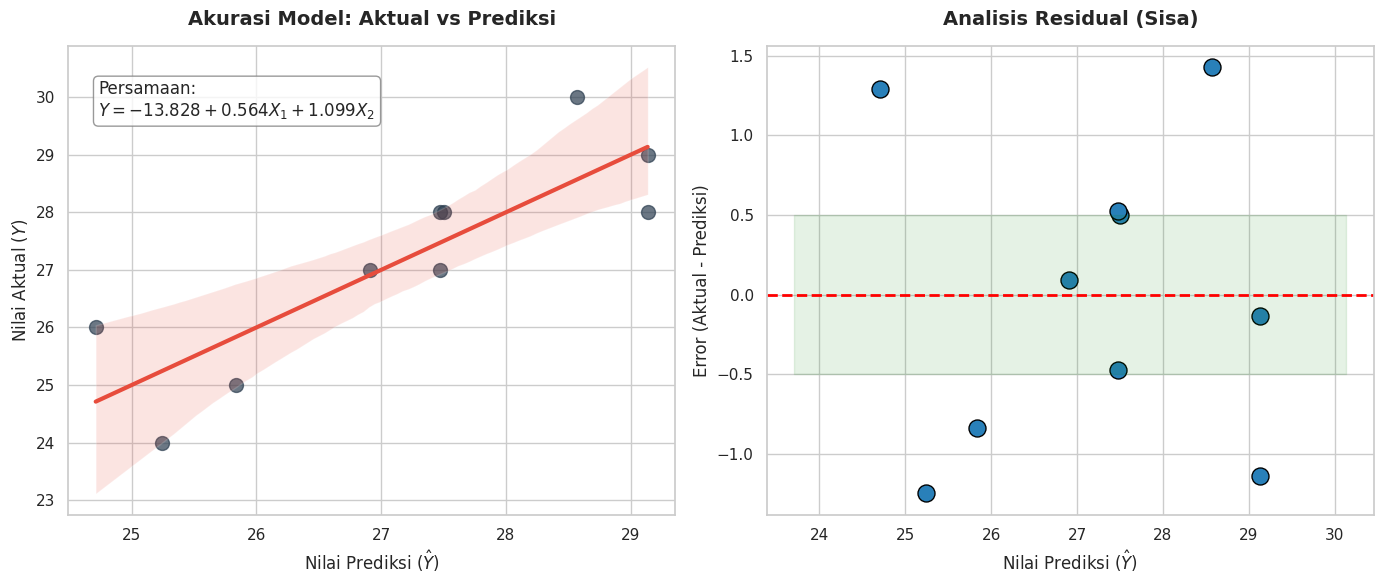

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Data Input (Sesuai Tabel)
x1 = np.array([45, 42, 44, 45, 43, 46, 44, 45, 44, 43])
x2 = np.array([16, 14, 15, 13, 13, 14, 16, 16, 15, 15])
y  = np.array([29, 24, 27, 25, 26, 28, 30, 28, 28, 27])

# Hasil Parameter dari perhitungan sebelumnya
a = -13.828
b1 = 0.564
b2 = 1.099

# 2. Membuat Meshgrid untuk Bidang Regresi (Slope Visualization)
x1_range = np.linspace(x1.min()-1, x1.max()+1, 10)
x2_range = np.linspace(x2.min()-1, x2.max()+1, 10)
X1_mesh, X2_mesh = np.meshgrid(x1_range, x2_range)
Y_pred = a + (b1 * X1_mesh) + (b2 * X2_mesh)

# 3. Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d') # Gunakan add_subplot
# Plot Titik Data Asli
ax.scatter(x1, x2, y, color='red', s=100, label='Data Aktual', edgecolors='black', alpha=0.8)

# Plot Bidang Regresi (Slope/Garis Prediksi)
surf = ax.plot_surface(X1_mesh, X2_mesh, Y_pred, alpha=0.3, cmap='viridis', antialiased=True)

# Garis bantu (Error/Residual)
for i in range(len(y)):
    ax.plot([x1[i], x1[i]], [x2[i], x2[i]], [y[i], a + b1*x1[i] + b2*x2[i]],
            color='gray', linestyle='--', linewidth=1)

# Labeling yang Eye-Catching
ax.set_xlabel('Variabel X1', fontsize=12, fontweight='bold')
ax.set_ylabel('Variabel X2', fontsize=12, fontweight='bold')
ax.set_zlabel('Variabel Y', fontsize=12, fontweight='bold')
ax.set_title('Visualisasi 3D Regresi Linear Berganda\n$Y = -13.828 + 0.564X_1 + 1.099X_2$',
             fontsize=15, pad=20)

plt.legend()
plt.show()